Using germancredit dataset as example.

In [1]:
import ssl
from ucimlrepo import fetch_ucirepo

ssl._create_default_https_context = ssl._create_unverified_context
statlog_german_credit_data = fetch_ucirepo(id=144)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets.squeeze().map({1:0, 2:1})
X.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


Import woe encoder.

In [2]:
from scorecard import ChiMergeWoeEncoder, DecisionTreeWoeEncoder

woe_encoder = ChiMergeWoeEncoder()
# woe_encoder = DecisionTreeWoeEncoder()
X_woe = woe_encoder.fit_transform(X, y)
X_woe.head()

,Attribute3,Attribute8,Attribute17,Attribute11,Attribute13,Attribute18,Attribute20,Attribute9,Attribute14,Attribute10,Attribute19,Attribute1,Attribute15,Attribute12,Attribute4,Attribute2,Attribute16,Attribute6,Attribute7,Attribute5
0,-0.733741,0.157300,-0.022780,0.001153,-0.108214,0.002816,0.034867,-0.165548,-0.121179,-0.000525,-0.098638,0.818099,-0.194156,-0.461035,-0.410063,-1.280934,0.010822,-0.704246,-0.235566,0.054361
1,0.088319,-0.190473,-0.022780,0.017335,0.528844,0.002816,0.034867,0.235341,-0.121179,-0.000525,0.064691,0.401392,-0.194156,-0.461035,-0.410063,0.766329,0.010822,0.271358,0.032103,-0.251314
2,-0.733741,-0.190473,-0.097164,-0.054941,-0.971861,-0.015409,0.034867,-0.165548,-0.121179,-0.000525,0.064691,-1.176263,-0.194156,-0.461035,0.606136,-0.195356,0.010822,0.271358,-0.394415,-0.147325
3,0.088319,-0.190473,-0.022780,0.001153,-0.195120,-0.015409,0.034867,-0.165548,-0.121179,-0.587787,0.064691,0.818099,0.472604,0.028573,0.099235,0.766329,0.010822,0.271358,-0.394415,0.545017
4,0.085158,-0.064539,-0.022780,0.001153,0.354821,-0.015409,0.034867,-0.165548,-0.121179,-0.000525,0.064691,0.818099,0.472604,0.586082,0.359200,0.011834,0.010822,0.271358,0.032103,0.646627


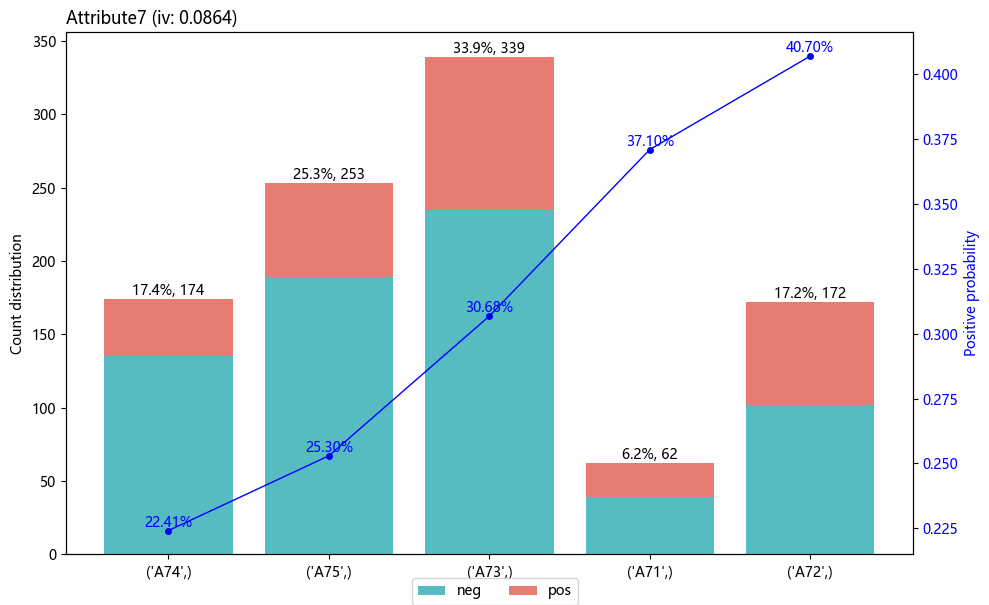

In [3]:
woe_encoder.plot(feature_name='Attribute7')
# woe_encoder.plot()  # Plot all features.

In [4]:
iv = woe_encoder.iv_table
iv

,variable,total_iv
0,Attribute1,0.666012
1,Attribute2,0.305067
2,Attribute3,0.293234
3,Attribute5,0.289018
4,Attribute6,0.196010
5,Attribute13,0.182028
6,Attribute4,0.169093
7,Attribute12,0.112638
8,Attribute7,0.086434
9,Attribute15,0.083293


Filter features with iv >= 0.02.

In [5]:
variables = iv.loc[iv['total_iv'] >= 0.02, 'variable'].tolist()
bins = dict(filter(lambda x: x[0] in variables, woe_encoder.bins_result_.items()))

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_woe[variables], y, test_size=0.25, random_state=1, stratify=y)
print('train', y_train.value_counts())
print('test', y_test.value_counts())

train class
0    525
1    225
Name: count, dtype: int64
test class
0    175
1     75
Name: count, dtype: int64


In [7]:
import plotly.express as px

corr = X_train.corr()
fig = px.imshow(corr, aspect='auto', width=800, height=600)
fig.show()

In [8]:
from sklearn.linear_model import LogisticRegressionCV

clf = LogisticRegressionCV(
    Cs=10,
    fit_intercept=True,
    cv=5,
    l1_ratios=(1,),
    solver='liblinear',
    random_state=1,
    use_legacy_attributes=False
)
clf.fit(X_train, y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","(1,)"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass set

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif['variable'] = variables
vif['coefficients'] = clf.coef_.reshape(-1,)
vif['vif'] = [variance_inflation_factor(X_train, i) for i in range(len(variables))]
vif.sort_values('vif', ascending=False)

,variable,coefficients,vif
7,Attribute12,0.611326,1.285660
9,Attribute15,-0.048675,1.239149
0,Attribute1,0.666093,1.164409
1,Attribute2,0.831473,1.155154
5,Attribute13,0.788907,1.130817
11,Attribute9,1.161880,1.121279
2,Attribute3,0.760514,1.115249
12,Attribute20,0.153068,1.115084
8,Attribute7,0.603517,1.114214
4,Attribute6,0.792207,1.091065


In [10]:
y_train_pred = clf.predict_proba(X_train)[:, 1]
y_test_pred = clf.predict_proba(X_test)[:, 1]

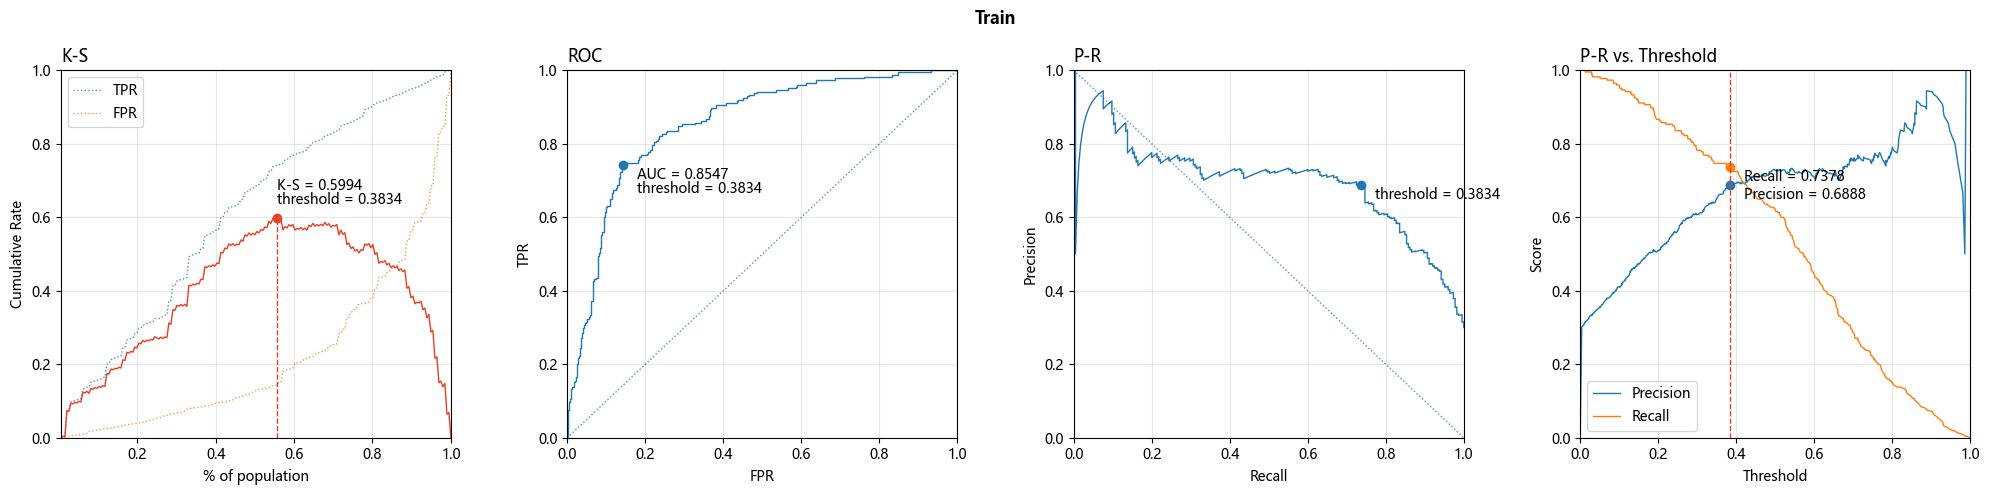

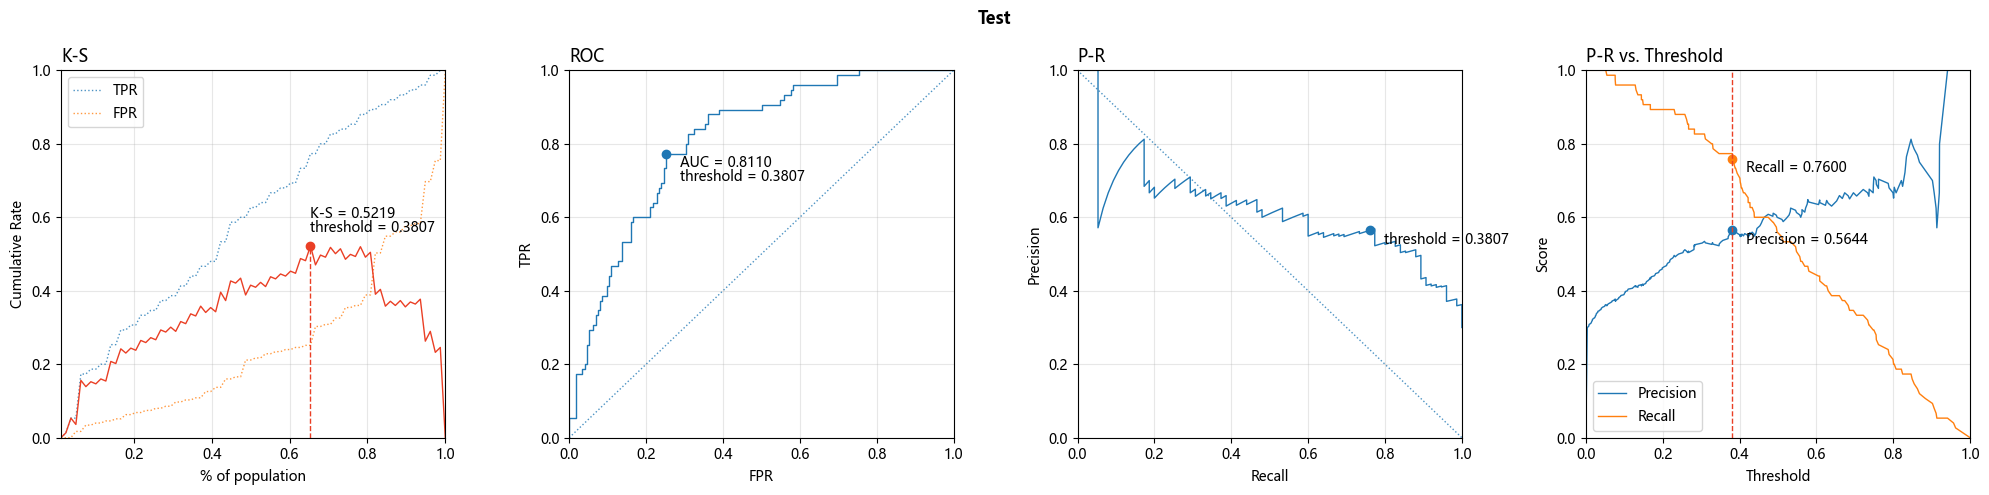

In [11]:
from scorecard import perf_eva

perf_eva(y_train, y_train_pred, 'Train')
perf_eva(y_test, y_test_pred, 'Test')

In [12]:
from scorecard import prob2score

total_bad_rate = y_train.sum() / y_train.size
odds0 = total_bad_rate / (1 - total_bad_rate)
y_train_score = prob2score(
    y_train_pred,
    points0=600,
    odds0=odds0,
    pdo=50
)
y_test_score = prob2score(
    y_test_pred,
    points0=600,
    odds0=odds0,
    pdo=50
)

In [13]:
from scorecard import gains_table

gains_table(
    label={'train': y_train, 'test': y_test},
    score={'train': y_train_score, 'test': y_test_score},
    bin_num=10
)

,dataset,bin,count,count_distr,neg,pos,cum_neg,cum_pos,posprob,lift
0,train,"[-inf, 472.0)",75,0.100000,18,57,18,57,0.760000,2.533333
1,train,"[472.0, 516.0)",75,0.100000,23,52,41,109,0.693333,2.311111
2,train,"[516.0, 563.0)",75,0.100000,28,47,69,156,0.626667,2.088889
3,train,"[563.0, 605.0)",74,0.098667,49,25,118,181,0.337838,1.126126
4,train,"[605.0, 636.0)",73,0.097333,61,12,179,193,0.164384,0.547945
5,train,"[636.0, 670.0)",77,0.102667,62,15,241,208,0.194805,0.649351
6,train,"[670.0, 698.0)",76,0.101333,68,8,309,216,0.105263,0.350877
7,train,"[698.0, 737.0)",71,0.094667,67,4,376,220,0.056338,0.187793
8,train,"[737.0, 801.0)",78,0.104000,74,4,450,224,0.051282,0.170940
9,train,"[801.0, inf)",76,0.101333,75,1,525,225,0.013158,0.043860


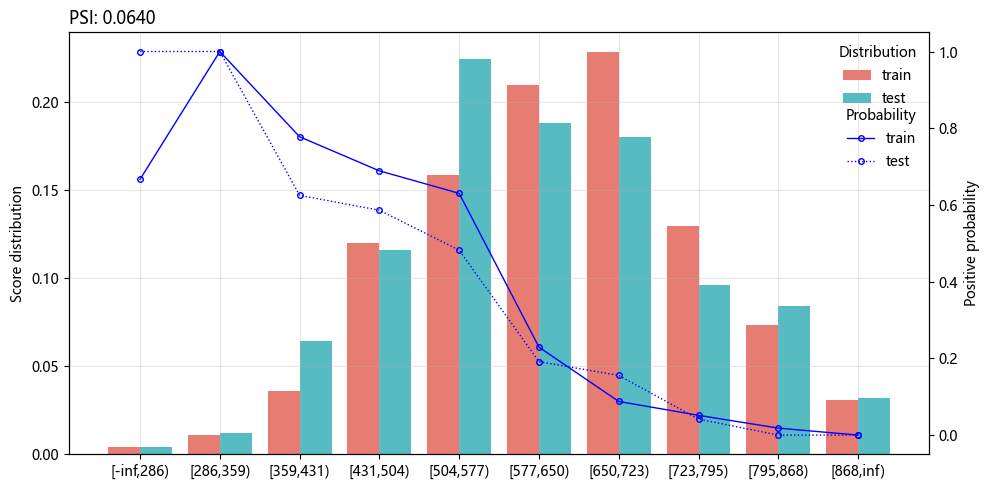

In [14]:
from scorecard import perf_psi

perf_psi(
    label={'train': y_train, 'test': y_test},
    score={'train': y_train_score, 'test': y_test_score}
)

In [15]:
from scorecard import scorecard

card = scorecard(
    bins,
    clf.intercept_,
    clf.coef_.reshape(-1,),
    variables,
    points0=600,
    odds0=odds0,
    pdo=50
)
card

,variable,bin,score
0,Base Line,None,596.0
1,Attribute1,"(A14,)",57.0
2,Attribute1,"(A13,)",19.0
3,Attribute1,"(A12,)",-19.0
4,Attribute1,"(A11,)",-39.0
...,...,...,...
69,Attribute15,"(A152,)",-1.0
70,Attribute15,"(A151,)",1.0
71,Attribute15,"(A153,)",2.0
72,Attribute20,"(A202,)",14.0


In [16]:
from scorecard import card2sql

print(card2sql(card, to_clipboard=False))

596.0 + 
        case
            when Attribute1 in ('A14') then 57.0
            when Attribute1 in ('A13') then 19.0
            when Attribute1 in ('A12') then -19.0
            when Attribute1 in ('A11') then -39.0
        end
         + 
        case
            when Attribute2 <= 8.0 then 77.0
            when Attribute2 <= 9.0 then 4.0
            when Attribute2 <= 10.0 then 76.0
            when Attribute2 <= 12.0 then 12.0
            when Attribute2 <= 15.0 then 40.0
            when Attribute2 <= 18.0 then -20.0
            when Attribute2 <= 30.0 then -1.0
            else -46.0
        end
         + 
        case
            when Attribute3 in ('A34') then 40.0
            when Attribute3 in ('A33') then -5.0
            when Attribute3 in ('A32') then -5.0
            when Attribute3 in ('A31') then -62.0
            when Attribute3 in ('A30') then -75.0
        end
         + 
        case
            when Attribute4 in ('A48') then 114.0
            when Attribute4 i